# 01 — Exploración de Datos INE

**TFG: Spain's Migratory Flow**  
**Fuente:** Atlas de Distribución de Renta de los Hogares (INE - ADRH)  
**Granularidad disponible:** Municipio / Distrito / Sección censal  
**Cobertura temporal:** 2015–2023

### Archivos analizados
| # | Archivo | Indicadores |
|---|---------|-------------|
| 1 | `1_Indicadores_de_renta_media_y_mediana.csv` | Renta neta/bruta por persona y hogar, mediana |
| 2 | `2_Distribución_por_fuente_de_ingresos.csv` | % salario, pensiones, desempleo, otras prestaciones |
| 9 | `9_Índice_de_Gini_y_Distribución_de_la_renta_P80P20.csv` | Gini, ratio P80/P20 |
| 10 | `10_Indicadores_demográficos.csv` | Edad media, % menores 18, % mayores 65, hogares, población |

### Objetivo de este notebook
Entender la **estructura real** de los datos: niveles geográficos, indicadores disponibles,  
cobertura temporal, valores faltantes y anomalías antes de limpiar nada.

In [14]:
# ── Librerías ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Estilo visual ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Rutas (robusto: sube desde el notebook hasta encontrar /data) ──────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data' / 'renta_ine'

print('PROJECT_ROOT :', PROJECT_ROOT)
print('DATA_DIR     :', DATA_DIR)
print('Existe       :', DATA_DIR.exists())

FILES = {
    'renta':               DATA_DIR / '1.Indicadores de renta media y mediana.csv',
    'fuente_ing':          DATA_DIR / '2.Distribución por fuente de ingresos.csv',
    'umbrales_edad':       DATA_DIR / '4.Porcentaje de población con ingresos por unidad de consumo por debajo de determinados umbrales fijos por sexo y tramos de edad.csv',
    'umbrales_nacionalid': DATA_DIR / '5.Porcentaje de población con ingresos por unidad de consumo por debajo de determinados umbrales fijos por sexo y nacionalidad.csv',
    'gini':                DATA_DIR / '9.Índice de Gini y Distribución de la renta P80P20.csv',
    'demografico':         DATA_DIR / '10.Indicadores demográficos.csv',
}

# ── Constantes ─────────────────────────────────────────────────────────────────
ENCODING  = 'utf-8-sig'  # UTF-8 con BOM (formato estándar INE)
SEPARATOR = ';'          # separador de campos
NA_VALUES = ['..', '']   # '..' = dato no disponible en INE

# ── Mapa código INE → nombre de provincia ─────────────────────────────────────
COD_PROVINCIA = {
    '01':'Álava',        '02':'Albacete',     '03':'Alicante',    '04':'Almería',
    '05':'Ávila',        '06':'Badajoz',      '07':'Baleares',    '08':'Barcelona',
    '09':'Burgos',       '10':'Cáceres',      '11':'Cádiz',       '12':'Castellón',
    '13':'Ciudad Real',  '14':'Córdoba',      '15':'A Coruña',    '16':'Cuenca',
    '17':'Girona',       '18':'Granada',      '19':'Guadalajara', '20':'Gipuzkoa',
    '21':'Huelva',       '22':'Huesca',       '23':'Jaén',        '24':'León',
    '25':'Lleida',       '26':'La Rioja',     '27':'Lugo',        '28':'Madrid',
    '29':'Málaga',       '30':'Murcia',       '31':'Navarra',     '32':'Ourense',
    '33':'Asturias',     '34':'Palencia',     '35':'Las Palmas',  '36':'Pontevedra',
    '37':'Salamanca',    '38':'S.C. Tenerife','39':'Cantabria',   '40':'Segovia',
    '41':'Sevilla',      '42':'Soria',        '43':'Tarragona',   '44':'Teruel',
    '45':'Toledo',       '46':'Valencia',     '47':'Valladolid',  '48':'Bizkaia',
    '49':'Zamora',       '50':'Zaragoza',     '51':'Ceuta',       '52':'Melilla'
}

print('\n✅ Configuración cargada')
print(f'   Archivos configurados: {list(FILES.keys())}')
print('\nCSV encontrados en disco:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(' -', f.name)

PROJECT_ROOT : /workspaces/TFG_Spain-s_Migratory_Flow
DATA_DIR     : /workspaces/TFG_Spain-s_Migratory_Flow/data/renta_ine
Existe       : True

✅ Configuración cargada
   Archivos configurados: ['renta', 'fuente_ing', 'umbrales_edad', 'umbrales_nacionalid', 'gini', 'demografico']

CSV encontrados en disco:
 - 1.Indicadores de renta media y mediana.csv
 - 10.Indicadores demográficos.csv
 - 2.Distribución por fuente de ingresos.csv
 - 4.Porcentaje de población con ingresos por unidad de consumo por debajo de determinados umbrales fijos por sexo y tramos de edad.csv
 - 5.Porcentaje de población con ingresos por unidad de consumo por debajo de determinados umbrales fijos por sexo y nacionalidad.csv
 - 9.Índice de Gini y Distribución de la renta P80P20.csv


In [15]:
print('CSV encontrados:')
for f in sorted(DATA_DIR.glob('*.csv')):
    print(' -', f.name)

CSV encontrados:
 - 1.Indicadores de renta media y mediana.csv
 - 10.Indicadores demográficos.csv
 - 2.Distribución por fuente de ingresos.csv
 - 4.Porcentaje de población con ingresos por unidad de consumo por debajo de determinados umbrales fijos por sexo y tramos de edad.csv
 - 5.Porcentaje de población con ingresos por unidad de consumo por debajo de determinados umbrales fijos por sexo y nacionalidad.csv
 - 9.Índice de Gini y Distribución de la renta P80P20.csv


In [16]:
import psutil, os

ram = psutil.virtual_memory()
print(f'RAM total   : {ram.total / 1e9:.1f} GB')
print(f'RAM usada   : {ram.used  / 1e9:.1f} GB')
print(f'RAM libre   : {ram.available / 1e9:.1f} GB')

RAM total   : 8.3 GB
RAM usada   : 5.2 GB
RAM libre   : 3.2 GB


---
## 1. Carga y diagnóstico general

Cargamos cada archivo y generamos un resumen estructural antes de cualquier transformación.

In [17]:
import time, gc, psutil

resumen_archivos = {}

for nombre, path in FILES.items():
    t0 = time.time()

    df_muestra = pd.read_csv(
        path,
        sep=SEPARATOR,
        encoding=ENCODING,
        na_values=NA_VALUES,
        dtype=str,
        engine='c',
        low_memory=False,
        on_bad_lines='warn',
        nrows=50_000,
    )

    with open(path, 'r', encoding=ENCODING) as f:
        n_filas_total = sum(1 for _ in f) - 1

    elapsed = time.time() - t0
    ram_libre = psutil.virtual_memory().available / 1e9

    resumen_archivos[nombre] = {
        'path'         : path,
        'filas_total'  : n_filas_total,
        'filas_muestra': len(df_muestra),
        'columnas'     : list(df_muestra.columns),
        'n_cols'       : df_muestra.shape[1],
        'dtypes'       : df_muestra.dtypes.to_dict(),
        'nulos'        : df_muestra.isnull().sum().to_dict(),
        'muestra'      : df_muestra,
    }

    print(f'  ✓ {nombre:22s}  →  {n_filas_total:>10,.0f} filas totales | {df_muestra.shape[1]} cols  ({elapsed:.1f}s)  [RAM libre: {ram_libre:.1f}GB]')
    gc.collect()

# dfs apunta a las muestras — necesario para todas las celdas posteriores
dfs = {k: v['muestra'] for k, v in resumen_archivos.items()}

print('\n✅ Exploración completada — muestras de 50k filas por archivo en memoria')
print(f'   RAM usada total: {psutil.virtual_memory().used/1e9:.1f} GB')

  ✓ renta                   →   2,933,089 filas totales | 6 cols  (3.3s)  [RAM libre: 3.0GB]
  ✓ fuente_ing              →   2,507,850 filas totales | 6 cols  (2.1s)  [RAM libre: 3.0GB]
  ✓ umbrales_edad           →   1,924,249 filas totales | 8 cols  (2.0s)  [RAM libre: 3.0GB]
  ✓ umbrales_nacionalid     →   2,099,129 filas totales | 8 cols  (2.0s)  [RAM libre: 3.0GB]
  ✓ gini                    →   1,003,104 filas totales | 6 cols  (1.0s)  [RAM libre: 3.0GB]
  ✓ demografico             →   3,105,215 filas totales | 6 cols  (2.1s)  [RAM libre: 3.0GB]

✅ Exploración completada — muestras de 50k filas por archivo en memoria
   RAM usada total: 5.4 GB


In [18]:
# ── Inspección detallada por archivo ─────────────────────────────────────────
for nombre, info in resumen_archivos.items():
    df = info['muestra']
    print('=' * 70)
    print(f'📁  {nombre.upper()}')
    print(f'    Ruta    : {info["path"].name}')
    print(f'    Filas   : {info["filas_total"]:>10,.0f} totales  |  {info["filas_muestra"]:,} en muestra')
    print(f'    Columnas: {info["n_cols"]}')
    print()

    # Columnas y tipos
    print('  COLUMNAS:')
    for col in df.columns:
        n_nulos  = df[col].isnull().sum()
        n_unicos = df[col].nunique()
        ejemplo  = df[col].dropna().iloc[0] if df[col].notna().any() else 'N/A'
        print(f'    {col:<45s}  nulos={n_nulos:>5}  únicos={n_unicos:>7,}  ej: {str(ejemplo)[:40]}')

    print()

    # Muestra de las primeras 3 filas
    print('  PRIMERAS 3 FILAS:')
    print(df.head(3).to_string(index=False))
    print()

print('=' * 70)
print('✅ Inspección completada')

📁  RENTA
    Ruta    : 1.Indicadores de renta media y mediana.csv
    Filas   :  2,933,089 totales  |  50,000 en muestra
    Columnas: 6

  COLUMNAS:
    Municipios                                     nulos=    0  únicos=    147  ej: 01001 Alegría-Dulantzi
    Distritos                                      nulos= 7938  únicos=    190  ej: 0100101 Alegría-Dulantzi distrito 01
    Secciones                                      nulos=18198  únicos=    589  ej: 0100101001 Alegría-Dulantzi sección 0100
    Indicadores de renta media                     nulos=    0  únicos=      6  ej: Renta neta media por persona
    Periodo                                        nulos=    0  únicos=      9  ej: 2023
    Total                                          nulos=11814  únicos= 16,254  ej: 16.429

  PRIMERAS 3 FILAS:
            Municipios Distritos Secciones   Indicadores de renta media Periodo  Total
01001 Alegría-Dulantzi       NaN       NaN Renta neta media por persona    2023 16.429
01001 Ale

In [19]:
def resumen_dataset(nombre: str, df: pd.DataFrame) -> None:
    """
    Imprime un diagnóstico completo de un DataFrame del INE:
    forma, columnas, años, indicadores, niveles geográficos y nulos.
    """
    col_ind = df.columns[4]   # columna de indicadores (posición fija en todos los archivos)
    
    # Separador decimal mixto: '1_renta' usa punto, el resto usa coma
    total_str = df['Total'].dropna().astype(str)
    usa_coma  = total_str.str.contains(',').any()
    
    print(f'\n{"="*65}')
    print(f'  📄  {nombre.upper()}')
    print(f'{"="*65}')
    print(f'  Shape          : {df.shape[0]:,} filas × {df.shape[1]} columnas')
    print(f'  Columnas       : {list(df.columns)}')
    print(f'  Años           : {sorted(df["Periodo"].dropna().unique())}')
    print(f'  Decimal Total  : {"coma (,)" if usa_coma else "punto (.)"}')
    
    # Indicadores disponibles
    print(f'\n  Indicadores ({col_ind}):')
    for v in df[col_ind].dropna().unique():
        print(f'    • {v}')
    
    # Niveles geográficos
    n_mun  = ((df['Distritos'].isna()) & (df['Secciones'].isna())).sum()
    n_dist = ((df['Distritos'].notna()) & (df['Secciones'].isna())).sum()
    n_sec  = (df['Secciones'].notna()).sum()
    total  = len(df)
    print(f'\n  Nivel geográfico:')
    print(f'    Municipio  : {n_mun:>9,} ({n_mun/total*100:.1f}%)')
    print(f'    Distrito   : {n_dist:>9,} ({n_dist/total*100:.1f}%)')
    print(f'    Sección    : {n_sec:>9,} ({n_sec/total*100:.1f}%)')
    
    # Nulos en Total
    nulos = df['Total'].isna().sum()
    print(f'\n  NaN en Total   : {nulos:,} ({nulos/total*100:.2f}%)')
    print(f'  Provincias     : {df["Municipios"].str.extract(r"^(\d{2})")[0].nunique()} de 52')


for nombre, df in dfs.items():
    resumen_dataset(nombre, df)


  📄  RENTA
  Shape          : 50,000 filas × 6 columnas
  Columnas       : ['Municipios', 'Distritos', 'Secciones', 'Indicadores de renta media', 'Periodo', 'Total']
  Años           : ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
  Decimal Total  : punto (.)

  Indicadores (Periodo):
    • 2023
    • 2022
    • 2021
    • 2020
    • 2019
    • 2018
    • 2017
    • 2016
    • 2015

  Nivel geográfico:
    Municipio  :     7,938 (15.9%)
    Distrito   :    10,260 (20.5%)
    Sección    :    31,802 (63.6%)

  NaN en Total   : 11,814 (23.63%)
  Provincias     : 3 de 52

  📄  FUENTE_ING
  Shape          : 50,000 filas × 6 columnas
  Columnas       : ['Municipios', 'Distritos', 'Secciones', 'Distribución por fuente de ingresos', 'Periodo', 'Total']
  Años           : ['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023']
  Decimal Total  : coma (,)

  Indicadores (Periodo):
    • 2023
    • 2022
    • 2021
    • 2020
    • 2019
    • 2018
    •

---
## 2. Distribución de datos por nivel geográfico

Visualizamos cuántas observaciones hay en cada nivel (municipio / distrito / sección) para cada fuente.

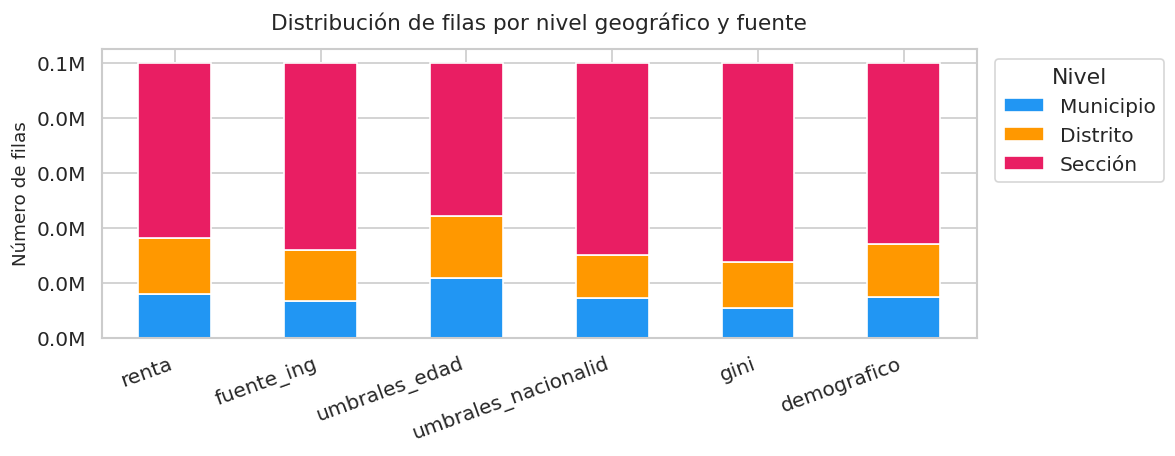


📊 Tabla resumen:


AttributeError: 'DataFrame' object has no attribute 'applymap'

In [20]:
niveles_data = []
for nombre, df in dfs.items():
    n_mun  = ((df['Distritos'].isna()) & (df['Secciones'].isna())).sum()
    n_dist = ((df['Distritos'].notna()) & (df['Secciones'].isna())).sum()
    n_sec  = (df['Secciones'].notna()).sum()
    niveles_data.append({'fuente': nombre, 'Municipio': n_mun, 'Distrito': n_dist, 'Sección': n_sec})

df_niveles = pd.DataFrame(niveles_data).set_index('fuente')

fig, ax = plt.subplots(figsize=(10, 4))
df_niveles.plot(kind='bar', stacked=True, ax=ax,
                color=['#2196F3', '#FF9800', '#E91E63'])
ax.set_title('Distribución de filas por nivel geográfico y fuente', pad=12)
ax.set_ylabel('Número de filas')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(title='Nivel', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print('\n📊 Tabla resumen:')
print(df_niveles.applymap(lambda x: f'{x:,.0f}').to_string())

---
## 3. Valores faltantes por fuente y año

Los valores `..` del INE (dato no disponible) son distintos de los NaN puros.  
Aquí analizamos **ambos** a nivel de municipio para el análisis posterior.

In [ ]:
fig_fuentes = len(dfs)
ncols = 3 if fig_fuentes >= 3 else fig_fuentes
nrows = (fig_fuentes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))

# Aseguramos que axes sea un array 1D
if isinstance(axes, np.ndarray):
    axes = axes.flatten()
else:
    axes = np.array([axes])

for i, (nombre, df) in enumerate(dfs.items()):
    # Filtrar solo nivel municipio
    df_mun = df[(df['Distritos'].isna()) & (df['Secciones'].isna())].copy()

    nulos_por_anio = (
        df_mun.groupby('Periodo')['Total']
        .apply(lambda s: s.isna().sum() / len(s) * 100)
        .reset_index(name='pct_nulo')
    )

    ax = axes[i]
    ax.bar(nulos_por_anio['Periodo'].astype(str),
           nulos_por_anio['pct_nulo'],
           color='#E53935', alpha=0.8)
    ax.set_title(f'{nombre} — % NaN en Total (nivel municipio)')
    ax.set_ylabel('% faltante')
    ax.set_ylim(0, max(nulos_por_anio['pct_nulo'].max() * 1.3, 5))
    ax.tick_params(axis='x', rotation=45)

    # Anotar el valor en cada barra
    for _, row in nulos_por_anio.iterrows():
        if row['pct_nulo'] > 0:
            ax.text(str(row['Periodo']), row['pct_nulo'] + 0.1,
                    f"{row['pct_nulo']:.1f}%", ha='center', fontsize=8)

# Ocultar subplots sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Valores faltantes por año — Nivel municipio', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Cobertura de municipios por provincia y año

¿Cuántos municipios tiene cada provincia en los datos? ¿Es consistente entre años?

In [ ]:
# Usar el archivo de renta como referencia de cobertura geográfica
df_renta = dfs['renta'].copy()
df_mun   = df_renta[(df_renta['Distritos'].isna()) & (df_renta['Secciones'].isna())].copy()
df_mun['cod_provincia'] = df_mun['Municipios'].str.extract(r'^(\d{2})')
df_mun['nombre_prov']   = df_mun['cod_provincia'].map(COD_PROVINCIA)

# Filtrar solo el indicador base para no duplicar municipios
indicador_ref = 'Renta neta media por persona'
col_ind = df_renta.columns[4]
df_ref  = df_mun[df_mun[col_ind] == indicador_ref]

cobertura = (
    df_ref.groupby(['cod_provincia', 'nombre_prov', 'Periodo'])
    ['Municipios'].nunique()
    .reset_index(name='n_municipios')
)

# Heatmap: provincias × años
pivot = cobertura.pivot_table(
    index='nombre_prov', columns='Periodo', values='n_municipios', fill_value=0
)

fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.3,
            cbar_kws={'label': 'Nº municipios'}, ax=ax)
ax.set_title('Municipios con datos por provincia y año (Renta neta media por persona)', pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Provincia')
plt.tight_layout()
plt.show()

---
## 5. Distribución de la renta neta por persona (2023)

Primer vistazo al indicador principal del TFG a nivel municipio.

In [ ]:
df_renta = dfs['renta'].copy()
col_ind  = df_renta.columns[4]

# Filtrar: nivel municipio, indicador base, 2023
mask = (
    (df_renta['Distritos'].isna()) &
    (df_renta['Secciones'].isna()) &
    (df_renta[col_ind] == 'Renta neta media por persona') &
    (df_renta['Periodo'] == '2023')
)
df_2023 = df_renta[mask].copy()
df_2023['valor'] = pd.to_numeric(df_2023['Total'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df_2023['valor'].dropna(), bins=60, color='#1976D2', edgecolor='white', alpha=0.85)
axes[0].axvline(df_2023['valor'].median(), color='#E53935', linestyle='--', linewidth=1.5,
                label=f"Mediana: {df_2023['valor'].median():,.0f} €")
axes[0].axvline(df_2023['valor'].mean(), color='#FF9800', linestyle='--', linewidth=1.5,
                label=f"Media: {df_2023['valor'].mean():,.0f} €")
axes[0].set_title('Distribución renta neta media por persona (2023, nivel municipio)')
axes[0].set_xlabel('€ / persona')
axes[0].set_ylabel('Nº municipios')
axes[0].legend()

# Boxplot por rango de renta
bins   = [0, 10000, 14000, 18000, 25000, 100000]
labels = ['<10k', '10-14k', '14-18k', '18-25k', '>25k']
df_2023['rango'] = pd.cut(df_2023['valor'], bins=bins, labels=labels)
rango_count = df_2023['rango'].value_counts().sort_index()
axes[1].bar(rango_count.index.astype(str), rango_count.values, color='#42A5F5', edgecolor='white')
axes[1].set_title('Municipios por rango de renta (2023)')
axes[1].set_xlabel('Rango de renta')
axes[1].set_ylabel('Nº municipios')
for idx, val in enumerate(rango_count.values):
    axes[1].text(idx, val + 5, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print('\n📊 Estadísticas descriptivas — Renta neta media por persona (2023):')
print(df_2023['valor'].describe().round(0).to_string())

---
## 6. Evolución temporal por indicador (mediana nacional)

¿Cómo evoluciona cada indicador a nivel nacional entre 2015 y 2023?

In [ ]:
def plot_evolucion(df_raw: pd.DataFrame, nombre: str, title_prefix: str) -> None:
    """
    Genera un subplot por cada indicador mostrando la evolución temporal
    de la mediana nacional a nivel de municipio.
    """
    col_ind = df_raw.columns[4]
    
    # Filtrar nivel municipio
    df_mun = df_raw[(df_raw['Distritos'].isna()) & (df_raw['Secciones'].isna())].copy()
    
    # Convertir Total a numérico (manejar coma decimal)
    df_mun['valor'] = (
        df_mun['Total'].astype(str)
        .str.replace(',', '.', regex=False)
        .pipe(pd.to_numeric, errors='coerce')
    )
    df_mun['Periodo'] = pd.to_numeric(df_mun['Periodo'], errors='coerce')
    
    indicadores = df_mun[col_ind].dropna().unique()
    n = len(indicadores)
    ncols = min(n, 3)
    nrows = (n + ncols - 1) // ncols
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    
    for i, ind in enumerate(indicadores):
        sub = df_mun[df_mun[col_ind] == ind]
        evo = sub.groupby('Periodo')['valor'].agg(['median', 'mean', 'std']).reset_index()
        
        axes[i].plot(evo['Periodo'], evo['median'], marker='o', linewidth=2,
                     color='#1976D2', label='Mediana')
        axes[i].fill_between(
            evo['Periodo'],
            evo['median'] - evo['std'],
            evo['median'] + evo['std'],
            alpha=0.15, color='#1976D2', label='±1 SD'
        )
        axes[i].set_title(ind, fontsize=10)
        axes[i].set_xlabel('Año')
        axes[i].legend(fontsize=8)
        axes[i].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    # Ocultar subplots vacíos
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'{title_prefix} — Evolución temporal (mediana nacional, nivel municipio)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# Ejecutar para los 6 datasets
plot_evolucion(dfs['renta'],               'renta',               '📈 Indicadores de Renta')
plot_evolucion(dfs['fuente_ing'],          'fuente_ing',          '💼 Fuentes de Ingreso')
plot_evolucion(dfs['umbrales_edad'],       'umbrales_edad',       '⚠️ Bajo umbral por edad')
plot_evolucion(dfs['umbrales_nacionalid'], 'umbrales_nacionalid', '⚠️ Bajo umbral por nacionalidad')
plot_evolucion(dfs['gini'],                'gini',                '⚖️ Gini y P80/P20')
plot_evolucion(dfs['demografico'],         'demografico',         '👥 Indicadores Demográficos')

---
## 7. Top y Bottom 10 provincias — Renta neta media por persona (2023)

Agregamos a nivel provincial calculando la mediana de todos los municipios de cada provincia.

In [ ]:
df_renta = dfs['renta'].copy()
col_ind  = df_renta.columns[4]

mask = (
    (df_renta['Distritos'].isna()) &
    (df_renta['Secciones'].isna()) &
    (df_renta[col_ind] == 'Renta neta media por persona') &
    (df_renta['Periodo'] == '2023')
)
df_prov = df_renta[mask].copy()
df_prov['valor']         = pd.to_numeric(df_prov['Total'], errors='coerce')
df_prov['cod_provincia'] = df_prov['Municipios'].str.extract(r'^(\d{2})')
df_prov['nombre_prov']   = df_prov['cod_provincia'].map(COD_PROVINCIA)

ranking = (
    df_prov.groupby(['cod_provincia', 'nombre_prov'])['valor']
    .median()
    .reset_index(name='renta_mediana')
    .sort_values('renta_mediana', ascending=False)
)

top10    = ranking.head(10)
bottom10 = ranking.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, titulo, color in [
    (axes[0], top10,    '🏆 Top 10 provincias — Renta más alta', '#43A047'),
    (axes[1], bottom10, '📉 Bottom 10 provincias — Renta más baja', '#E53935'),
]:
    bars = ax.barh(data['nombre_prov'], data['renta_mediana'], color=color, alpha=0.85)
    ax.set_xlabel('Renta neta media por persona (€) — mediana municipal')
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}€'))
    for bar, val in zip(bars, data['renta_mediana']):
        ax.text(bar.get_width() - 200, bar.get_y() + bar.get_height()/2,
                f'{val:,.0f}€', va='center', ha='right', fontsize=9, color='white', fontweight='bold')

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.suptitle('Ranking provincial — Renta neta media por persona (2023)', fontsize=14)
plt.tight_layout()
plt.show()

print('\n📊 Ranking completo (52 provincias):')
print(ranking.to_string(index=False))

---
## 8. Mapa de calor: Gini por provincia y año

Visualizamos la desigualdad interna de cada provincia a lo largo del tiempo.

In [ ]:
df_gini  = dfs['gini'].copy()
col_ind  = df_gini.columns[4]

mask = (
    (df_gini['Distritos'].isna()) &
    (df_gini['Secciones'].isna()) &
    (df_gini[col_ind] == 'Índice de Gini')
)
df_g = df_gini[mask].copy()
df_g['valor']         = df_g['Total'].astype(str).str.replace(',', '.').pipe(pd.to_numeric, errors='coerce')
df_g['cod_provincia'] = df_g['Municipios'].str.extract(r'^(\d{2})')
df_g['nombre_prov']   = df_g['cod_provincia'].map(COD_PROVINCIA)
df_g['Periodo']       = pd.to_numeric(df_g['Periodo'], errors='coerce')

pivot_gini = (
    df_g.groupby(['nombre_prov', 'Periodo'])['valor']
    .median()
    .reset_index()
    .pivot(index='nombre_prov', columns='Periodo', values='valor')
)

fig, ax = plt.subplots(figsize=(14, 16))
sns.heatmap(pivot_gini, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.3, cbar_kws={'label': 'Índice de Gini'},
            vmin=20, vmax=40, ax=ax)
ax.set_title('Índice de Gini por provincia y año (mediana municipal)', pad=12)
ax.set_xlabel('Año')
ax.set_ylabel('Provincia')
plt.tight_layout()
plt.show()

---
## 9. Perfil demográfico por provincia (2023)

Radar / tabla de los indicadores demográficos clave para detectar patrones de envejecimiento.

In [ ]:
df_dem  = dfs['demografico'].copy()
col_ind = df_dem.columns[4]

mask = (
    (df_dem['Distritos'].isna()) &
    (df_dem['Secciones'].isna()) &
    (df_dem['Periodo'] == '2023')
)
df_d = df_dem[mask].copy()
df_d['valor']         = df_d['Total'].astype(str).str.replace(',', '.').pipe(pd.to_numeric, errors='coerce')
df_d['cod_provincia'] = df_d['Municipios'].str.extract(r'^(\d{2})')
df_d['nombre_prov']   = df_d['cod_provincia'].map(COD_PROVINCIA)

# Tabla pivot: provincia × indicador
perfil = (
    df_d.groupby(['nombre_prov', col_ind])['valor']
    .median()
    .reset_index()
    .pivot(index='nombre_prov', columns=col_ind, values='valor')
    .round(1)
)

print('📊 Perfil demográfico por provincia (2023) — mediana municipal:\n')
print(perfil.to_string())

# Scatter: % mayores 65 vs Edad media
if 'Porcentaje de población de 65 y más años' in perfil.columns and 'Edad media de la población' in perfil.columns:
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(perfil['Edad media de la población'],
               perfil['Porcentaje de población de 65 y más años'],
               s=60, alpha=0.7, color='#7B1FA2')
    for prov, row in perfil.iterrows():
        if pd.notna(row.get('Edad media de la población')) and pd.notna(row.get('Porcentaje de población de 65 y más años')):
            ax.annotate(prov, (row['Edad media de la población'],
                               row['Porcentaje de población de 65 y más años']),
                        fontsize=7, alpha=0.8)
    ax.set_xlabel('Edad media de la población')
    ax.set_ylabel('% población ≥65 años')
    ax.set_title('Envejecimiento por provincia (2023) — mediana municipal')
    plt.tight_layout()
    plt.show()

---
## 10. Resumen ejecutivo

Tabla de diagnóstico final: lo que hay que abordar en `02_ine.ipynb`.

In [ ]:
resumen = []
for nombre, df in dfs.items():
    col_ind = df.columns[4]
    df_mun  = df[(df['Distritos'].isna()) & (df['Secciones'].isna())]
    n_total = len(df_mun)
    n_nulos = df_mun['Total'].isna().sum()
    n_ind   = df[col_ind].nunique()
    
    # Detectar separador decimal
    usa_coma = df['Total'].dropna().astype(str).str.contains(',').any()
    
    resumen.append({
        'Fuente':          nombre,
        'Filas (municipio)': f'{n_total:,}',
        'Indicadores':     n_ind,
        '% NaN Total':     f'{n_nulos/n_total*100:.1f}%' if n_total > 0 else 'N/A',
        'Decimal':         'coma (,)' if usa_coma else 'punto (.)',
        'Años':            '2015–2023',
        'Acción limpieza': (
            'Reemplazar coma→punto en Total; NaN ya tratados' if usa_coma
            else 'Total ya numérico; NaN ya tratados'
        )
    })

df_resumen = pd.DataFrame(resumen)
print('=' * 80)
print('📋 RESUMEN EJECUTIVO — Input para notebook 02_ine.ipynb')
print('=' * 80)
print(df_resumen.to_string(index=False))
print()
print('🔑 DECISIONES DE DISEÑO tomadas en exploración:')
print('   1. Nivel de análisis → MUNICIPIO (descartar distritos y secciones)')
print('   2. Periodo → 2015-2023 (9 años, sin huecos en el INE)')
print('   3. Separador decimal mixto → normalizar todo a punto (.)')
print('   4. NaN y ".." → ya capturados con na_values=[".", ""] en lectura')
print('   5. Agregación a provincia → mediana de municipios (robusta a outliers)')
print('   6. Clave join final → cod_provincia + año')